# Extreme Values, Quantiles, and Value at Risk

Mean and standard deviation describe the typical behavior of a return series; they say almost nothing about how bad the bad days can get. This notebook builds the toolkit that fills that gap: quantiles and Value at Risk (VaR) for everyday tail measurement, Expected Shortfall for what happens *beyond* VaR, Extreme Value Theory for estimating risk at confidence levels beyond what the data directly shows, and joint tail analysis for what happens to correlation when multiple assets are stressed at once.

1. Simulating a two-asset return system with realistic fat tails and crash-period correlation breakdown
2. Quantiles and the empirical return distribution
3. Value at Risk: historical, parametric, and Cornish-Fisher methods
4. Expected Shortfall (Conditional VaR)
5. Rolling VaR and volatility through time, with breach diagnostics
6. Extreme Value Theory: Peaks-Over-Threshold and the Generalized Pareto Distribution
7. Backtesting: exceedance rates and the Kupiec test
8. Joint tail dependence between two assets

## 1. Simulating the Data

Two equity-like return series, 20 years of daily data, with two deliberate features real markets share and a constant-variance, constant-correlation model would miss entirely: **volatility clustering with crash episodes** (elevated volatility and negative drift together, producing genuine fat tails), and **correlation that rises sharply during those same crash periods**, the classic "diversification disappears exactly when you need it most" phenomenon.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, genpareto

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (7, 4.2), 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'grid.alpha': 0.35,
})

rng = np.random.default_rng(77)

n_years = 20
n_days = n_years * 252
dates = pd.bdate_range('2004-01-02', periods=n_days)

crash_windows = [(1550, 1700), (3550, 3750), (4700, 4850)]
crash_flag = np.zeros(n_days, dtype=bool)
for s, e in crash_windows:
    crash_flag[s:e] = True

base_corr, crash_corr = 0.4, 0.90
mu_daily = np.array([0.09, 0.07]) / 252
sigma_base = np.array([0.16, 0.20]) / np.sqrt(252)
vol_mult = np.ones(n_days)
for s, e in crash_windows:
    vol_mult[s:e] = 2.5

returns = np.zeros((n_days, 2))
for t in range(n_days):
    corr = crash_corr if crash_flag[t] else base_corr
    cov = np.array([[1, corr], [corr, 1]])
    z = rng.multivariate_normal([0, 0], cov)
    returns[t] = mu_daily + sigma_base * vol_mult[t] * z

for s, e in crash_windows:
    dur = e - s
    returns[s:e, 0] += np.linspace(-0.006, -0.001, dur)
    returns[s:e, 1] += np.linspace(-0.007, -0.0015, dur)
    rec_len = min(int(dur * 1.5), n_days - e)
    returns[e:e+rec_len, 0] += np.linspace(0.003, 0.0004, rec_len)
    returns[e:e+rec_len, 1] += np.linspace(0.0035, 0.0005, rec_len)

df = pd.DataFrame(returns * 100, index=dates, columns=['Equity_A', 'Equity_B'])

print(f"Simulated {n_days} trading days ({n_years} years)")
print(f"Skewness: {df.skew().round(3).to_dict()}")
print(f"Excess kurtosis: {df.kurtosis().round(3).to_dict()}")
print(f"Overall correlation: {df.corr().iloc[0,1]:.3f}")
print(f"Correlation in crash periods: {df[crash_flag].corr().iloc[0,1]:.3f}")
print(f"Correlation in calm periods: {df[~crash_flag].corr().iloc[0,1]:.3f}")

Simulated 5040 trading days (20 years)
Skewness: {'Equity_A': -0.202, 'Equity_B': -0.15}
Excess kurtosis: {'Equity_A': 3.628, 'Equity_B': 3.435}
Overall correlation: 0.622
Correlation in crash periods: 0.912
Correlation in calm periods: 0.398


**Diagram - cumulative return with crash periods shaded.**

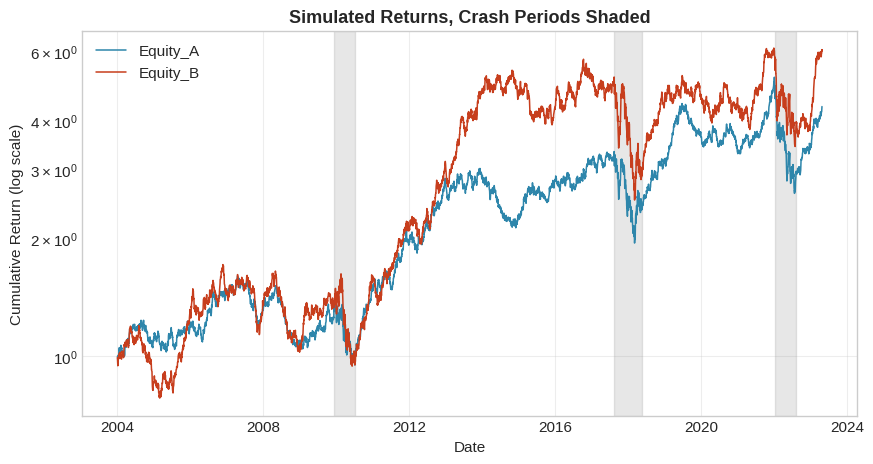

In [2]:
fig, ax = plt.subplots(figsize=(10, 5))
cum = (1 + df/100).cumprod()
ax.plot(cum.index, cum['Equity_A'], color='#2E86AB', linewidth=1.1, label='Equity_A')
ax.plot(cum.index, cum['Equity_B'], color='#C73E1D', linewidth=1.1, label='Equity_B')
for s, e in crash_windows:
    ax.axvspan(dates[s], dates[e], color='#888888', alpha=0.2)
ax.set_yscale('log')
ax.set_xlabel('Date'); ax.set_ylabel('Cumulative Return (log scale)')
ax.set_title('Simulated Returns, Crash Periods Shaded')
ax.legend()
plt.show()

## 2. Quantiles and the Return Distribution

The $\alpha$-quantile of a return distribution is the value below which a fraction $\alpha$ of outcomes fall. Value at Risk, defined properly in Section 3, is nothing more than a specific quantile of the loss distribution, so understanding the shape of the empirical distribution comes first.

In [3]:
r = df['Equity_A']
quantile_levels = [0.001, 0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99, 0.999]
quantile_table = pd.DataFrame({'Quantile': quantile_levels,
                                'Return (%)': [np.percentile(r, 100*q) for q in quantile_levels]})
print(quantile_table.to_string(index=False))

 Quantile  Return (%)
    0.001   -6.123391
    0.010   -3.701984
    0.050   -1.820933
    0.100   -1.363676
    0.500    0.047071
    0.900    1.467578
    0.950    1.916955
    0.990    3.286160
    0.999    5.612405


**Diagram - return distribution with a normal overlay, and a QQ-plot.** The histogram's peak is taller and its tails are longer than the fitted normal curve, and the QQ-plot's characteristic S-curve confirms it: this is exactly what excess kurtosis looks like.

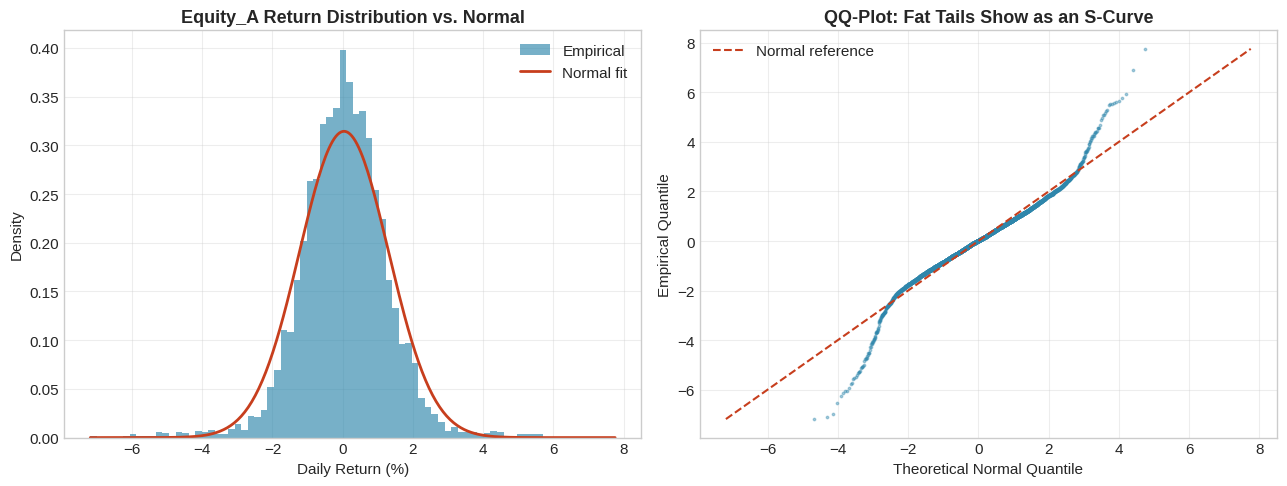

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(r, bins=80, density=True, color='#2E86AB', alpha=0.65, label='Empirical')
x_grid = np.linspace(r.min(), r.max(), 300)
ax.plot(x_grid, norm.pdf(x_grid, r.mean(), r.std()), color='#C73E1D', linewidth=2, label='Normal fit')
ax.set_xlabel('Daily Return (%)'); ax.set_ylabel('Density')
ax.set_title('Equity_A Return Distribution vs. Normal')
ax.legend()

ax = axes[1]
sorted_r = np.sort(r)
n = len(sorted_r)
theoretical_q = norm.ppf((np.arange(1, n+1) - 0.5) / n, r.mean(), r.std())
ax.scatter(theoretical_q, sorted_r, s=3, color='#2E86AB', alpha=0.4)
lims = [min(theoretical_q.min(), sorted_r.min()), max(theoretical_q.max(), sorted_r.max())]
ax.plot(lims, lims, color='#C73E1D', linewidth=1.5, linestyle='--', label='Normal reference')
ax.set_xlabel('Theoretical Normal Quantile'); ax.set_ylabel('Empirical Quantile')
ax.set_title('QQ-Plot: Fat Tails Show as an S-Curve')
ax.legend()

plt.tight_layout()
plt.show()

## 3. Value at Risk: Three Methods

$\text{VaR}_\alpha$ answers: "with probability $\alpha$, losses will not exceed this amount over the given horizon." Three ways to estimate it from the same data:

- **Historical VaR** — the empirical $(1-\alpha)$ quantile of realized returns directly, no distributional assumption at all.
- **Parametric (Gaussian) VaR** — assumes returns are normally distributed: $\text{VaR}_\alpha = -(\mu + z_\alpha \sigma)$, where $z_\alpha$ is the standard normal quantile.
- **Cornish-Fisher VaR** — adjusts the normal quantile for the sample's own skewness and kurtosis, a cheap, closed-form correction for fat tails without needing a full non-normal model.

In [5]:
def historical_var(returns, alpha):
    return -np.percentile(returns, 100 * (1 - alpha))

def parametric_var(returns, alpha):
    mu, sigma = returns.mean(), returns.std()
    return -(mu + norm.ppf(1 - alpha) * sigma)

def cornish_fisher_var(returns, alpha):
    mu, sigma = returns.mean(), returns.std()
    skew, kurt = returns.skew(), returns.kurtosis()
    z = norm.ppf(1 - alpha)
    z_cf = z + (z**2 - 1)*skew/6 + (z**3 - 3*z)*kurt/24 - (2*z**3 - 5*z)*skew**2/36
    return -(mu + z_cf * sigma)

var_table = []
for alpha in [0.95, 0.99]:
    var_table.append({
        'Confidence': f'{alpha:.0%}',
        'Historical VaR': historical_var(r, alpha),
        'Parametric VaR': parametric_var(r, alpha),
        'Cornish-Fisher VaR': cornish_fisher_var(r, alpha),
    })
var_df = pd.DataFrame(var_table).set_index('Confidence')
print(var_df.round(3))

            Historical VaR  Parametric VaR  Cornish-Fisher VaR
Confidence                                                    
95%                  1.821           2.050               2.029
99%                  3.702           2.914               4.159


**Diagram - VaR thresholds on the return distribution.** All three methods agree reasonably well at 95%; at 99%, deep in the tail where the normal assumption matters most, parametric VaR visibly understates the risk relative to the fat-tailed empirical and Cornish-Fisher estimates.

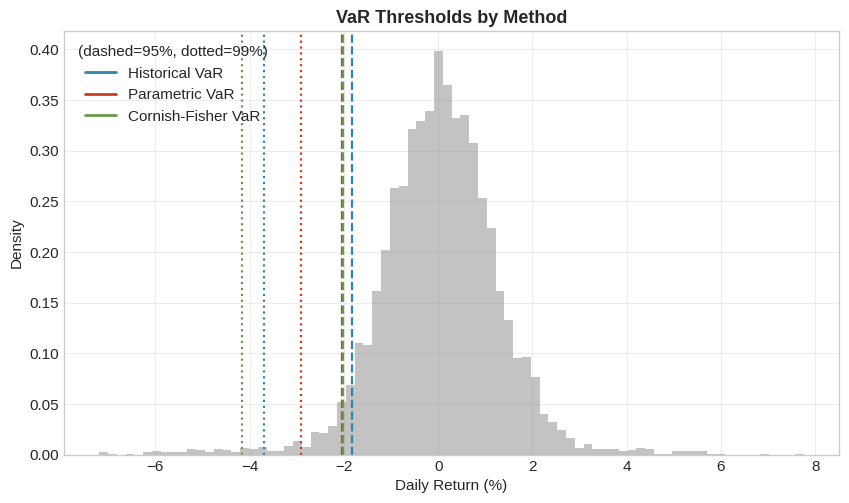

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.hist(r, bins=80, density=True, color='#888888', alpha=0.5)
colors_var = {'Historical VaR': '#2E86AB', 'Parametric VaR': '#C73E1D', 'Cornish-Fisher VaR': '#6A994E'}
for method, c in colors_var.items():
    for alpha, ls in [(0.95, '--'), (0.99, ':')]:
        v = var_df.loc[f'{alpha:.0%}', method]
        ax.axvline(-v, color=c, linestyle=ls, linewidth=1.6,
                   label=f'{method} ({alpha:.0%})' if ls == '--' else None)
handles = [plt.Line2D([0],[0], color=c, lw=2) for c in colors_var.values()]
ax.legend(handles, colors_var.keys(), loc='upper left', title='(dashed=95%, dotted=99%)')
ax.set_xlabel('Daily Return (%)'); ax.set_ylabel('Density')
ax.set_title('VaR Thresholds by Method')
plt.show()

## 4. Expected Shortfall (Conditional VaR)

VaR answers "how bad, at this confidence level" but says nothing about *how much worse* things get on the days that breach it. **Expected Shortfall** (ES, also called CVaR) is the average loss conditional on being in the tail beyond VaR:

$$\text{ES}_\alpha = E[\,\text{Loss} \mid \text{Loss} > \text{VaR}_\alpha\,]$$

ES is also a *coherent* risk measure (it satisfies subadditivity: the ES of a combined portfolio never exceeds the sum of its parts' ES), a property plain VaR lacks, one reason regulatory frameworks have shifted toward it.

In [7]:
def historical_es(returns, alpha):
    v = historical_var(returns, alpha)
    tail = returns[returns <= -v]
    return -tail.mean()

def parametric_es(returns, alpha):
    mu, sigma = returns.mean(), returns.std()
    z = norm.ppf(1 - alpha)
    return -(mu - sigma * norm.pdf(z) / (1 - alpha))

es_table = []
for alpha in [0.95, 0.99]:
    es_table.append({
        'Confidence': f'{alpha:.0%}',
        'Historical VaR': historical_var(r, alpha),
        'Historical ES': historical_es(r, alpha),
        'Parametric VaR': parametric_var(r, alpha),
        'Parametric ES': parametric_es(r, alpha),
    })
es_df = pd.DataFrame(es_table).set_index('Confidence')
print(es_df.round(3))
print("\nES is always >= VaR at the same confidence level, by construction: it averages the tail beyond VaR.")

            Historical VaR  Historical ES  Parametric VaR  Parametric ES
Confidence                                                              
95%                  1.821          2.869           2.050          2.580
99%                  3.702          4.970           2.914          3.344

ES is always >= VaR at the same confidence level, by construction: it averages the tail beyond VaR.


## 5. Rolling VaR and Volatility Through Time

Risk isn't static, a VaR figure calculated once on the full sample tells you nothing about whether *today's* risk looks like the crash-period risk or the calm-period risk. Two rolling estimates: a **252-day rolling historical VaR**, and a **RiskMetrics-style EWMA volatility** ($\lambda=0.94$, weighting recent squared returns more heavily than distant ones) feeding a rolling parametric VaR that reacts faster to regime changes.

In [8]:
window = 252
roll_hist_var95 = r.rolling(window).apply(lambda x: -np.percentile(x, 5), raw=True)

lam = 0.94
ewma_var = r.pow(2).ewm(alpha=1 - lam).mean()
ewma_vol = np.sqrt(ewma_var)
roll_param_var95 = -(r.rolling(window).mean() + norm.ppf(0.05) * ewma_vol)

breaches = r < -roll_hist_var95
valid = breaches.notna().sum()
print(f"Rolling historical VaR(95%) breaches: {breaches.sum()} of {valid} observations "
      f"({100*breaches.sum()/valid:.2f}%, expected ~5%)")

Rolling historical VaR(95%) breaches: 291 of 5040 observations (5.77%, expected ~5%)


**Diagram - returns, rolling VaR bands, and breaches.** The rolling VaR band widens visibly during each crash window as the trailing window fills with turbulent days, then narrows again once calm returns; breach markers cluster exactly where the band was still catching up to a regime shift, the central practical weakness of any backward-looking risk measure.

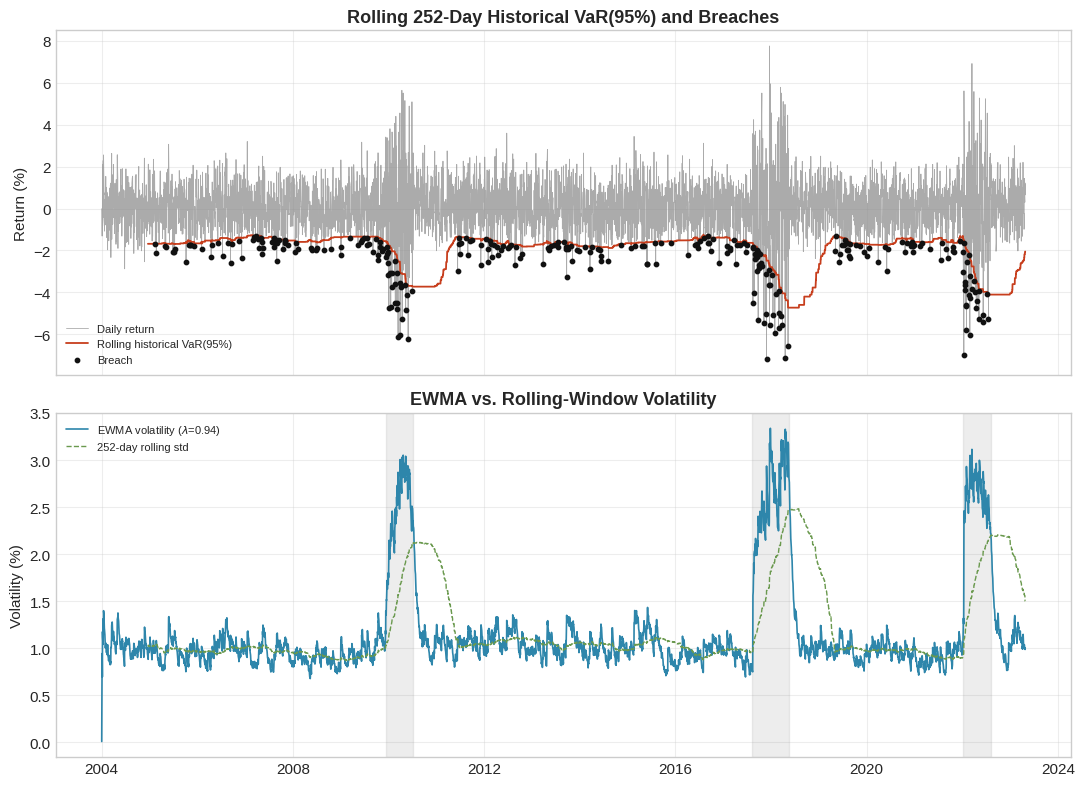

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

ax = axes[0]
ax.plot(r.index, r, color='#888888', linewidth=0.6, alpha=0.7, label='Daily return')
ax.plot(r.index, -roll_hist_var95, color='#C73E1D', linewidth=1.3, label='Rolling historical VaR(95%)')
ax.scatter(r.index[breaches], r[breaches], color='#111111', s=10, zorder=5, label='Breach')
ax.set_ylabel('Return (%)'); ax.set_title('Rolling 252-Day Historical VaR(95%) and Breaches')
ax.legend(fontsize=8, loc='lower left')

ax = axes[1]
ax.plot(r.index, ewma_vol, color='#2E86AB', linewidth=1.2, label='EWMA volatility ($\\lambda$=0.94)')
ax.plot(r.index, r.rolling(window).std(), color='#6A994E', linewidth=1.0, linestyle='--', label='252-day rolling std')
for s, e in crash_windows:
    ax.axvspan(dates[s], dates[e], color='#888888', alpha=0.15)
ax.set_ylabel('Volatility (%)'); ax.set_title('EWMA vs. Rolling-Window Volatility')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Extreme Value Theory: Peaks-Over-Threshold

Historical VaR at 99.5% or 99.9% confidence needs data far out in the tail that simply may not exist in the sample (20 years of daily data has only about 25 observations beyond the 99.5th percentile). **Extreme Value Theory** solves this by modeling the tail directly: the Pickands-Balkema-de Haan theorem says that, for a high enough threshold $u$, the distribution of *exceedances* over that threshold converges to a **Generalized Pareto Distribution (GPD)**, regardless of the distribution of the data as a whole:

$$P(X - u \le x \mid X > u) \to G_{\xi,\beta}(x) = 1 - \left(1 + \xi\frac{x}{\beta}\right)^{-1/\xi}$$

Fitting $\xi$ (shape) and $\beta$ (scale) to the observed exceedances then lets the tail be extrapolated to confidence levels the raw data can't reach directly.

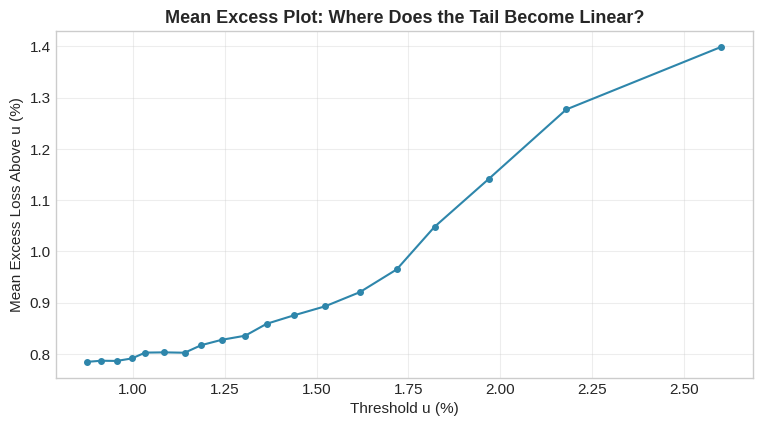

In [10]:
losses = -r
u_grid = np.percentile(losses, np.arange(80, 99, 1))
mean_excess = [np.mean(losses[losses > u] - u) for u in u_grid]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(u_grid, mean_excess, 'o-', color='#2E86AB', markersize=4)
ax.set_xlabel('Threshold u (%)'); ax.set_ylabel('Mean Excess Loss Above u (%)')
ax.set_title('Mean Excess Plot: Where Does the Tail Become Linear?')
plt.show()

A roughly linear mean-excess plot signals a good threshold range for the GPD approximation; the threshold below is chosen from the point where that linearity begins.

In [11]:
threshold = np.percentile(losses, 92)
exceedances = losses[losses > threshold] - threshold
xi, loc, beta = genpareto.fit(exceedances, floc=0)

print(f"Threshold (92nd percentile of losses): {threshold:.3f}%")
print(f"Exceedances: {len(exceedances)} of {len(losses)} ({100*len(exceedances)/len(losses):.1f}%)")
print(f"Fitted GPD: shape (xi) = {xi:.4f}, scale (beta) = {beta:.4f}")
print(f"(xi > 0 confirms a fat, Pareto-type tail, consistent with the excess kurtosis in Section 2)")

def evt_var(alpha, threshold, xi, beta, n, n_u):
    q = 1 - alpha
    return threshold + (beta / xi) * (((n / n_u) * q) ** (-xi) - 1)

def evt_es(var_, threshold, xi, beta):
    return (var_ + beta - xi * threshold) / (1 - xi)

n, n_u = len(losses), len(exceedances)
evt_table = []
for alpha in [0.95, 0.99, 0.995, 0.999]:
    v = evt_var(alpha, threshold, xi, beta, n, n_u)
    evt_table.append({'Confidence': f'{alpha:.1%}', 'EVT VaR': v, 'EVT ES': evt_es(v, threshold, xi, beta),
                       'Historical VaR': historical_var(r, alpha) if alpha <= 0.99 else np.nan})
evt_df = pd.DataFrame(evt_table).set_index('Confidence')
print()
print(evt_df.round(3))

Threshold (92nd percentile of losses): 1.523%
Exceedances: 404 of 5040 (8.0%)
Fitted GPD: shape (xi) = 0.3333, scale (beta) = 0.6152
(xi > 0 confirms a fat, Pareto-type tail, consistent with the excess kurtosis in Section 2)

            EVT VaR  EVT ES  Historical VaR
Confidence                                 
95.0%         1.838   2.917           1.821
99.0%         3.371   5.217           3.702
99.5%         4.331   6.657             NaN
99.9%         7.634  11.611             NaN


**Diagram - the fitted GPD tail vs. the empirical exceedance distribution.** EVT smooths and extrapolates the tail beyond the range the raw data can support directly, the entire point of fitting a parametric model to just the extreme observations rather than the whole sample.

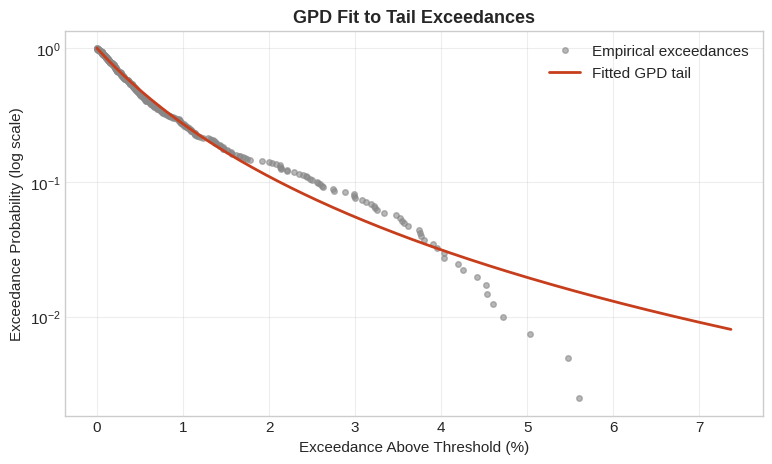

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
sorted_exc = np.sort(exceedances)
empirical_cdf = np.arange(1, len(sorted_exc)+1) / len(sorted_exc)
ax.plot(sorted_exc, 1 - empirical_cdf, 'o', color='#888888', markersize=4, alpha=0.6, label='Empirical exceedances')
x_tail = np.linspace(0, sorted_exc.max()*1.3, 200)
ax.plot(x_tail, 1 - genpareto.cdf(x_tail, xi, loc=0, scale=beta), color='#C73E1D', linewidth=2, label='Fitted GPD tail')
ax.set_yscale('log')
ax.set_xlabel('Exceedance Above Threshold (%)'); ax.set_ylabel('Exceedance Probability (log scale)')
ax.set_title('GPD Fit to Tail Exceedances')
ax.legend()
plt.show()

## 7. Backtesting: Is the VaR Model Actually Calibrated?

A 95% VaR model should be breached about 5% of the time, no more, no less. Kupiec's Proportion-of-Failures test formalizes this as a likelihood-ratio test comparing the observed breach rate to the expected one; under correct calibration, the test statistic follows a $\chi^2_1$ distribution.

In [13]:
from scipy.stats import chi2

def kupiec_test(n, x, p):
    # n = observations, x = breaches, p = expected breach probability (1-alpha)
    if x == 0:
        lr = -2 * n * np.log(1 - p)
    elif x == n:
        lr = -2 * n * np.log(p)
    else:
        p_hat = x / n
        log_l0 = (n - x) * np.log(1 - p) + x * np.log(p)
        log_l1 = (n - x) * np.log(1 - p_hat) + x * np.log(p_hat)
        lr = -2 * (log_l0 - log_l1)
    return lr, 1 - chi2.cdf(lr, df=1)

backtest_rows = []
for alpha in [0.95, 0.99]:
    roll_hist_var_a = r.rolling(window).apply(lambda x: -np.percentile(x, 100*(1-alpha)), raw=True)
    roll_ewma_var_a = -(r.rolling(window).mean() + norm.ppf(1 - alpha) * ewma_vol)
    for name, var_series in [('Rolling Historical', roll_hist_var_a), ('Rolling EWMA Parametric', roll_ewma_var_a)]:
        valid = var_series.notna()
        breaches = int((r[valid] < -var_series[valid]).sum())
        n_obs = int(valid.sum())
        lr, pval = kupiec_test(n_obs, breaches, 1 - alpha)
        backtest_rows.append({'Confidence': f'{alpha:.0%}', 'Method': name, 'Breaches': breaches, 'N': n_obs,
                               'Breach rate': breaches/n_obs, 'Expected rate': 1-alpha,
                               'Kupiec LR': lr, 'p-value': pval})

backtest_df = pd.DataFrame(backtest_rows)
print(backtest_df.round(4).to_string(index=False))
print("\np-value < 0.05 rejects correct calibration. Both rolling methods struggle here, expected: the crash")
print("windows built into this data are exactly the kind of sudden regime shift a backward-looking rolling")
print("window is structurally slow to react to, part of the practical motivation for EVT and EWMA-style methods.")

Confidence                  Method  Breaches    N  Breach rate  Expected rate  Kupiec LR  p-value
       95%      Rolling Historical       291 4789       0.0608           0.05    10.9639   0.0009
       95% Rolling EWMA Parametric       203 4789       0.0424           0.05     6.1450   0.0132
       99%      Rolling Historical        74 4789       0.0155           0.01    12.3275   0.0004
       99% Rolling EWMA Parametric        22 4789       0.0046           0.01    17.6951   0.0000

p-value < 0.05 rejects correct calibration. Both rolling methods struggle here, expected: the crash
windows built into this data are exactly the kind of sudden regime shift a backward-looking rolling
window is structurally slow to react to, part of the practical motivation for EVT and EWMA-style methods.


## 8. Joint Tail Dependence

Single-asset VaR misses a critical portfolio-level risk: **correlation is not constant**, and it tends to rise exactly when both assets are having a bad day, precisely when diversification benefits are needed most. This was built into the simulation directly (Section 1: correlation 0.40 in calm periods, 0.91 during crashes); the two diagrams below make that visible from the returns data alone, with no reference to how it was generated.

Days both assets breach their individual 95% VaR simultaneously: 113 (2.24% of all days)
Of those joint-breach days, 86.7% fall inside a crash window (crash windows cover only 9.9% of the sample)


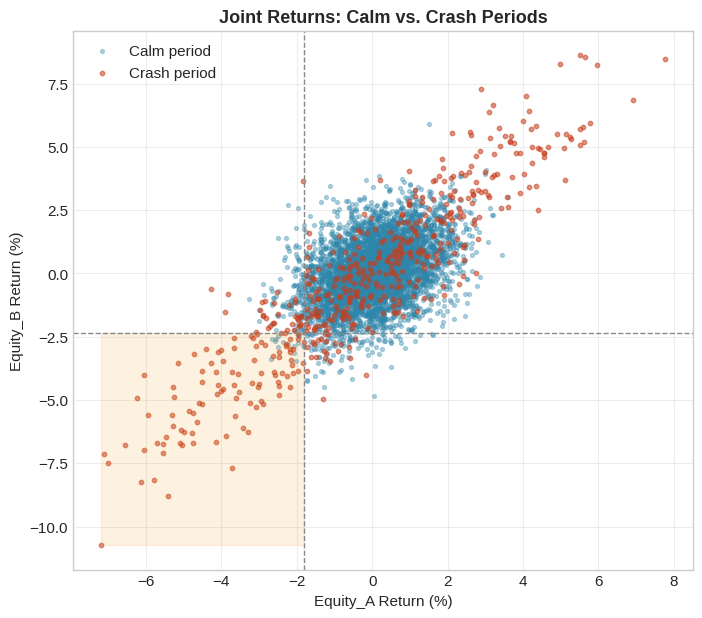

In [14]:
fig, ax = plt.subplots(figsize=(8, 7))
calm = ~crash_flag
ax.scatter(df.loc[calm, 'Equity_A'], df.loc[calm, 'Equity_B'], s=8, alpha=0.35, color='#2E86AB', label='Calm period')
ax.scatter(df.loc[crash_flag, 'Equity_A'], df.loc[crash_flag, 'Equity_B'], s=10, alpha=0.55, color='#C73E1D', label='Crash period')

var95_A, var95_B = historical_var(df['Equity_A'], 0.95), historical_var(df['Equity_B'], 0.95)
ax.axvline(-var95_A, color='#888888', linestyle='--', linewidth=1)
ax.axhline(-var95_B, color='#888888', linestyle='--', linewidth=1)
ax.fill_between([df['Equity_A'].min(), -var95_A], df['Equity_B'].min(), -var95_B, color='#F18F01', alpha=0.12)

ax.set_xlabel('Equity_A Return (%)'); ax.set_ylabel('Equity_B Return (%)')
ax.set_title('Joint Returns: Calm vs. Crash Periods')
ax.legend(loc='upper left')
plt.show()

joint_tail = ((df['Equity_A'] < -var95_A) & (df['Equity_B'] < -var95_B))
print(f"Days both assets breach their individual 95% VaR simultaneously: {joint_tail.sum()} "
      f"({100*joint_tail.sum()/len(df):.2f}% of all days)")
print(f"Of those joint-breach days, {100*joint_tail[crash_flag].sum()/joint_tail.sum():.1f}% fall inside a crash window "
      f"(crash windows cover only {100*crash_flag.sum()/len(df):.1f}% of the sample)")

**Diagram - rolling correlation.** The single clearest picture of tail dependence: correlation is unremarkable most of the time and spikes sharply, every single time, exactly inside each shaded crash window.

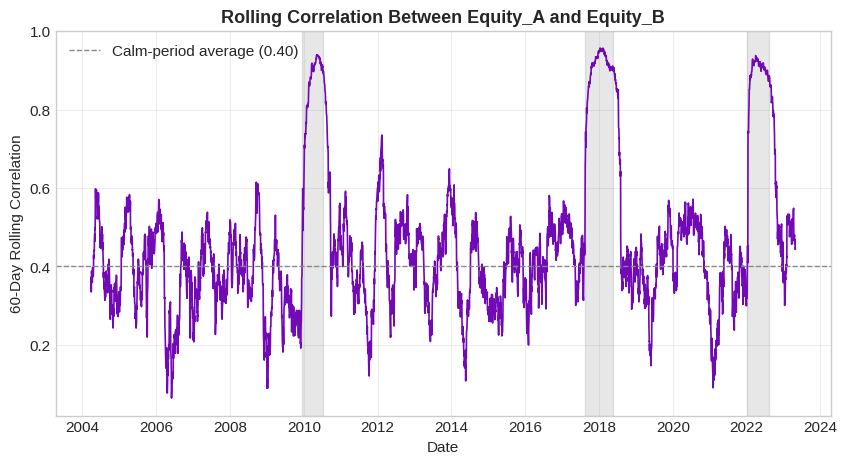

In [15]:
roll_corr = df['Equity_A'].rolling(60).corr(df['Equity_B'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(roll_corr.index, roll_corr, color='#7209B7', linewidth=1.2)
ax.axhline(base_corr, color='#888888', linestyle='--', linewidth=1, label=f'Calm-period average ({base_corr:.2f})')
for s, e in crash_windows:
    ax.axvspan(dates[s], dates[e], color='#888888', alpha=0.2)
ax.set_xlabel('Date'); ax.set_ylabel('60-Day Rolling Correlation')
ax.set_title('Rolling Correlation Between Equity_A and Equity_B')
ax.legend()
plt.show()